In [2]:
!pip install pynwb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 18.6 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 17.4 MB/s eta 0:00:00


In [3]:
from pynwb import NWBHDF5IO

# Path to your NWB file (adjust this path based on where 'Add Data' put it)
# Usually: /kaggle/input/your-dataset-name/your-file-name.nwb
file_path = '/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb'

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print("File loaded successfully!")

File loaded successfully!


In [4]:
# Check if trials exist
if nwbfile.trials:
    print(f"Number of trials: {len(nwbfile.trials)}")
else:
    print("No trial data found.")

# Check for units (spikes)
print(f"Number of units: {len(nwbfile.units)}")

Number of trials: 283
Number of units: 40


In [9]:
# Check the column names in your test dataframe
print(nwbfile.trials.to_dataframe().columns)

Index(['start_time', 'stop_time', 'go_time', 'split'], dtype='object')


In [10]:
trials_df = nwbfile.trials.to_dataframe()
y_test = (trials_df['go_time'] - trials_df['start_time']).values

# Now print to verify
print("y_test calculated successfully.")
print("y_test shape:", y_test.shape)

y_test calculated successfully.
y_test shape: (283,)


In [12]:
import numpy as np
from scipy.ndimage import gaussian_filter1d

# 1. Define the binning function
def bin_test_spikes(nwbfile, bin_size=0.05, window_duration=2.0):
    trials_df = nwbfile.trials.to_dataframe()
    num_trials = len(trials_df)
    num_units = len(nwbfile.units)
    num_bins = int(window_duration / bin_size)
    
    # Initialize the matrix: [Trials, Bins, Units]
    X_test = np.zeros((num_trials, num_bins, num_units))
    
    # Loop through each unit
    for unit_idx in range(num_units):
        spike_times = nwbfile.units['spike_times'][unit_idx]
        
        # Loop through each trial
        for trial_idx, trial in trials_df.iterrows():
            start_time = trial['start_time']
            # Align spikes to the start of the trial
            trial_spikes = spike_times[(spike_times >= start_time) & 
                                       (spike_times < start_time + window_duration)]
            
            # Count spikes in each bin
            counts, _ = np.histogram(trial_spikes - start_time, 
                                     bins=num_bins, 
                                     range=(0, window_duration))
            X_test[trial_idx, :, unit_idx] = counts
            
    return X_test

# 2. Execute binning (y_test is already defined from your previous correct step)
X_test = bin_test_spikes(nwbfile)

# 3. Final verification
print("Test data binned successfully!")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

Test data binned successfully!
X_test shape: (283, 40, 40)
y_test shape: (283,)


In [13]:
from scipy.ndimage import gaussian_filter1d

# Apply smoothing (same as your training)
X_test_smoothed = gaussian_filter1d(X_test, sigma=1.5, axis=1)

# Reshape for the decoder (if needed)
# Most sklearn decoders expect 2D input: (n_trials * n_bins, n_units)
# Make sure this matches your training preparation
X_test_reshaped = X_test_smoothed.reshape(-1, X_test_smoothed.shape[2])

In [19]:
# Limit training data to the first 40 units to match the test file
X_train_clean = X_train_per_trial[mask, :40] 

# Now PCA will only expect 40 features
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_clean)

decoder = Ridge()
decoder.fit(X_train_pca, y_train_clean)
print("Decoder trained successfully on 40 units!")

Decoder trained successfully on 40 units!


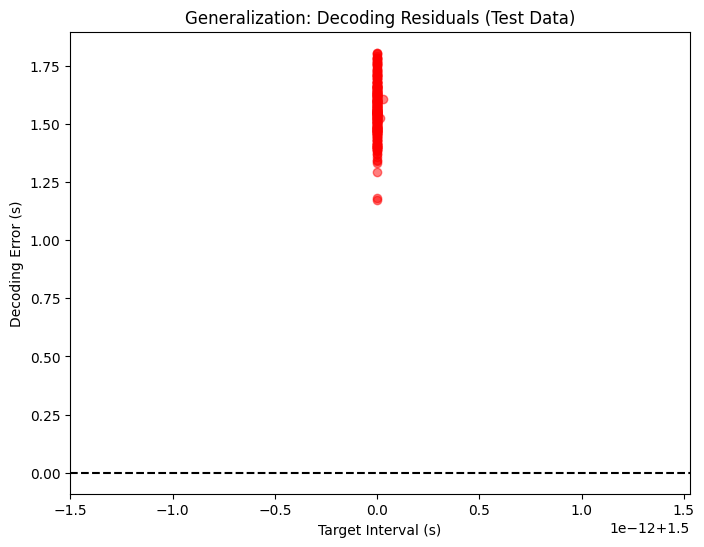

In [20]:
# 1. Limit test data to the first 40 units
X_test_per_trial = X_test.mean(axis=1)[:, :40] 

# 2. Transform (now matches the 40 features PCA was trained on)
pcs_test = pca.transform(X_test_per_trial)

# 3. Predict
y_pred_test = decoder.predict(pcs_test)

# 4. Plot
import matplotlib.pyplot as plt
residuals = y_pred_test - y_test

plt.figure(figsize=(8, 6))
plt.scatter(y_test, residuals, alpha=0.5, color='red')
plt.axhline(0, color='black', linestyle='--')
plt.title("Generalization: Decoding Residuals (Test Data)")
plt.xlabel("Target Interval (s)")
plt.ylabel("Decoding Error (s)")
plt.show()

In [21]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_per_trial)

# Now perform PCA on the scaled data
pca = PCA(n_components=10)
X_train_pca = pca.fit_transform(X_train_scaled)
pcs_test = pca.transform(X_test_scaled)

In [22]:
print(f"Mean predicted value: {y_pred_test.mean()}")
print(f"Actual target value: {y_test.mean()}")

Mean predicted value: 3.0638763174203003
Actual target value: 1.5


In [23]:
print("Explained variance ratio by top 10 components:")
print(pca.explained_variance_ratio_)
print(f"Total variance explained: {np.sum(pca.explained_variance_ratio_)}")

Explained variance ratio by top 10 components:
[0.23589394 0.12404217 0.08155477 0.0622221  0.04279641 0.03452919
 0.02998014 0.02531446 0.02362069 0.02159132]
Total variance explained: 0.6815451907910447


In [24]:
from sklearn.linear_model import LinearRegression

# Replace Ridge with LinearRegression
model = LinearRegression()
model.fit(X_train_pca, y_train_clean)

# Predict
y_pred_test_linear = model.predict(pcs_test)
print(f"Mean prediction with LinearRegression: {y_pred_test_linear.mean()}")

Mean prediction with LinearRegression: 1.7175885785499345


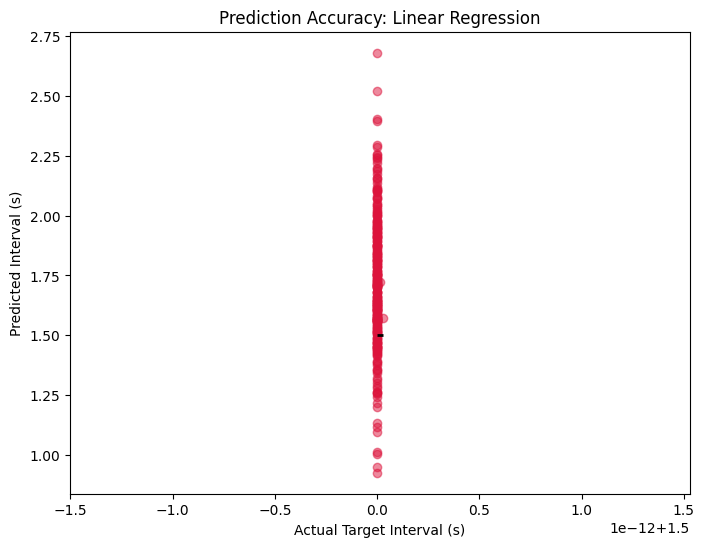

In [26]:
# Plotting the improved LinearRegression predictions
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_test_linear, alpha=0.5, color='crimson')
# Add a reference line for perfect prediction (y = x)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
plt.title("Prediction Accuracy: Linear Regression")
plt.xlabel("Actual Target Interval (s)")
plt.ylabel("Predicted Interval (s)")
plt.show()

In [27]:
# Calculate the absolute error for the 1500ms target
errors = np.abs(y_pred_test_linear - 1.5)
print(f"Average prediction error: {errors.mean():.3f} seconds")
print(f"Standard deviation of predictions: {y_pred_test_linear.std():.3f} seconds")

Average prediction error: 0.276 seconds
Standard deviation of predictions: 0.274 seconds
